# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.utils import get_root_directory
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import calendar
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
import gensim
from gensim.utils import simple_preprocess

## Google News Headlines

In [2]:
root_dir = get_root_directory()
processed_gn = pd.read_csv(f"{root_dir}\data\processed\Google_News_Headlines_data\google_news_headlines_data.csv")

In [3]:
processed_gn

,Date,News Headline,Publisher
0,2017-11-09,Hong Kong Fintech Innovation Lab Led with Bloc...,Forbes
1,2017-11-09,Decentralized Electricity Could be Blockchain’...,Cointelegraph
2,2017-11-09,Ethereum cryptocurrency value dropped due to w...,Inquirer.net
3,2017-11-09,Ambrosus: Digitalising the Global Trade with B...,Open Access Government
4,2017-11-09,Exchange Comparison: Kraken vs Bitstamp - Coin...,CoinCentral
...,...,...,...
156569,2024-08-11,Monero Price Prediction 2024-2030: A Good Inve...,Cryptopolitan
156570,2024-08-11,Could Bitcoin Crash? Celsius Slaps Tether with...,Cryptonews
156571,2024-08-11,SEC Addresses Final Court Ruling in Ripple Cas...,Bitcoin.com News
156572,2024-08-11,Best Top 5 Crypto to Buy (Short List) / X100 M...,Crypto News Flash


In [4]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Date           156574 non-null  object
 1   News Headline  156574 non-null  object
 2   Publisher      156574 non-null  object
dtypes: object(3)
memory usage: 3.6+ MB


In [5]:
processed_gn = processed_gn.astype('string')
processed_gn['Date'] = pd.to_datetime(processed_gn['Date'])

In [6]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           156574 non-null  datetime64[ns]
 1   News Headline  156574 non-null  string        
 2   Publisher      156574 non-null  string        
dtypes: datetime64[ns](1), string(2)
memory usage: 3.6 MB


In [7]:
publishers = list(processed_gn['Publisher'].unique()) 

In [8]:
sorted(publishers)

['#NAME?',
 '- Disrupt Africa',
 '032c',
 '06880',
 '1.00E+09',
 '1010 WINS',
 '106.9 KROC',
 '107.180.56.147',
 '10TV',
 '11Alive.com WXIA',
 '11Onze',
 '12news.com KPNX',
 '1337 Games',
 '13WHAM-TV',
 '13WMAZ.com',
 '13newsnow.com WVEC',
 '150sec',
 '15min',
 '1819 News',
 '1E9',
 '1Lurer',
 '1News',
 '2 News Oklahoma KJRH Tulsa',
 '218 News',
 '225 Baton Rouge',
 '24',
 '24 News HD',
 '24-7 Press Release',
 '24/7 Wall St.',
 '25 News KXXV and KRHD',
 '263chat.com',
 '360 Magazine',
 '365 Retail',
 '368.media',
 '36NG',
 '3BL Media',
 '3D Printing Industry',
 '3DPrint.com',
 '3Dnatives',
 '3FM',
 '3VB',
 '3news',
 '411mania.com',
 '48 Hills',
 '5 Dariya News',
 '5280 | The Denver Magazine',
 '69News WFMZ-TV',
 '6Sqft',
 '7NEWS',
 '8 Days',
 '80.lv',
 '90.5 WESA',
 '96FM Perth',
 '97.3 The Dawg',
 '97.9 WGRD',
 '99.co',
 '99Bitcoins',
 '99signals',
 '9News',
 '9News.com KUSA',
 '9to5Google',
 '9to5Mac',
 'A Journal of Musical Things',
 'A Wealth of Common Sense',
 'A&O Shearman',
 'A3

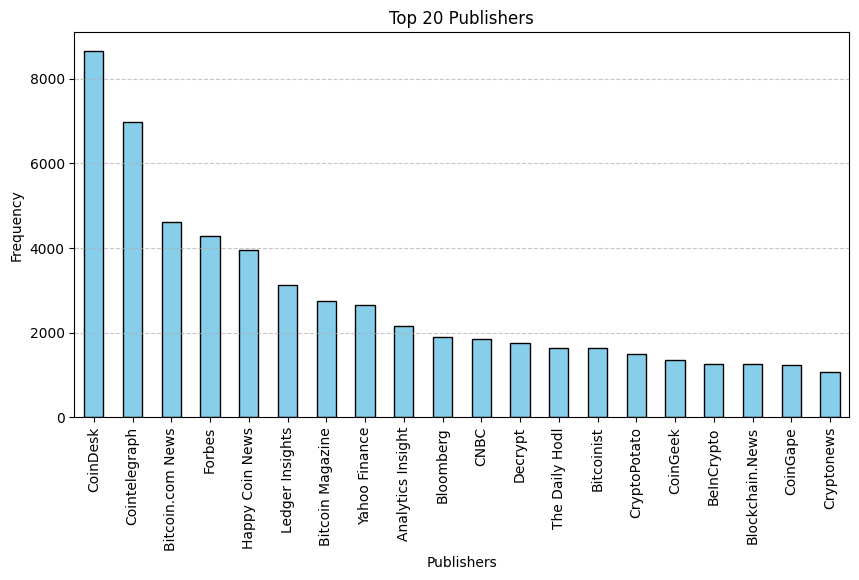

In [9]:
n = 20
top_n = processed_gn['Publisher'].value_counts().nlargest(n)
plt.figure(figsize=(10, 5))
top_n.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Publishers')
plt.ylabel('Frequency')
plt.title(f'Top {n} Publishers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [10]:
len(processed_gn['News Headline'].unique())

156574

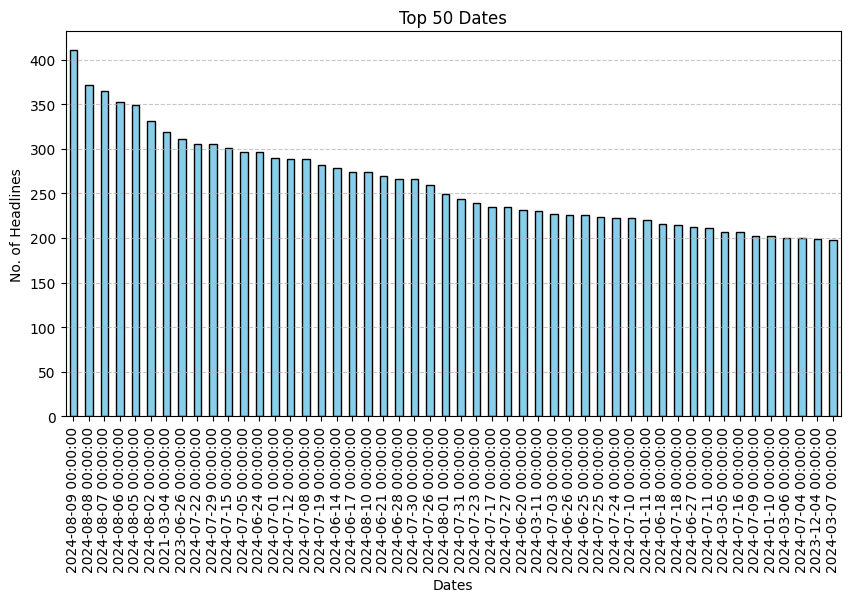

In [11]:
n = 50
top_n = processed_gn['Date'].value_counts().nlargest(n)
plt.figure(figsize=(10, 5))
top_n.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Dates')
plt.ylabel('No. of Headlines')
plt.title(f'Top {n} Dates')
plt.grid(axis='y', linestyle='--', alpha=0.7)

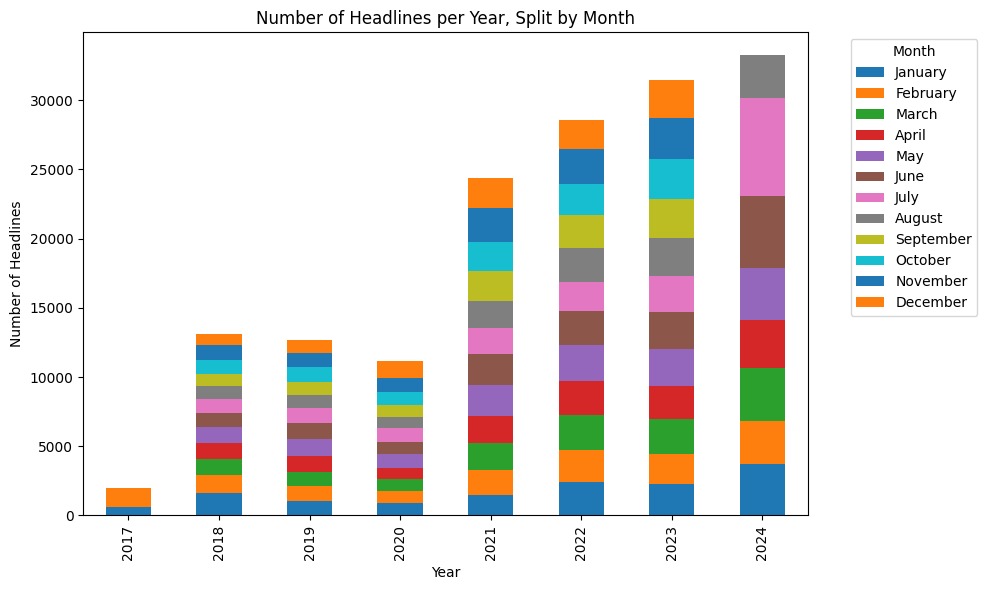

In [12]:
processed_gn['year'] = processed_gn['Date'].dt.year
processed_gn['month'] =processed_gn['Date'].dt.month

# Create a new column with month names (for plotting)
processed_gn['month_name'] = processed_gn['Date'].dt.month_name()

# Group by year and month name, then count the number of headlines
grouped = processed_gn.groupby(['year', 'month_name']).size().unstack(fill_value=0)

# Reorder the columns to follow the calendar month order
months_order = list(calendar.month_name)[1:]  # list from 'January' to 'December'
grouped = grouped.reindex(columns=months_order, fill_value=0)

# Plot the stacked bar chart
ax = grouped.plot(kind='bar', stacked=True, figsize=(10, 6))

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('Number of Headlines')
plt.title('Number of Headlines per Year, Split by Month')

# Place the legend outside the plot area for better visibility
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
processed_gn['length'] = processed_gn['News Headline'].apply(lambda x: len(x.split()))

In [14]:
extreme = list(processed_gn['News Headline'][processed_gn['length']==46])

In [15]:
processed_gn.describe()

,Date,year,month,length
count,156574,156574.000000,156574.000000,156574.000000
mean,2022-03-01 02:05:42.769552896,2021.686768,6.249684,13.191679
min,2017-11-09 00:00:00,2017.000000,1.000000,3.000000
25%,2021-01-07 00:00:00,2021.000000,3.000000,11.000000
50%,2022-07-04 00:00:00,2022.000000,6.000000,13.000000
75%,2023-10-30 00:00:00,2023.000000,9.000000,15.000000
max,2024-08-11 00:00:00,2024.000000,12.000000,46.000000
std,NaN,1.943338,3.337317,3.454630


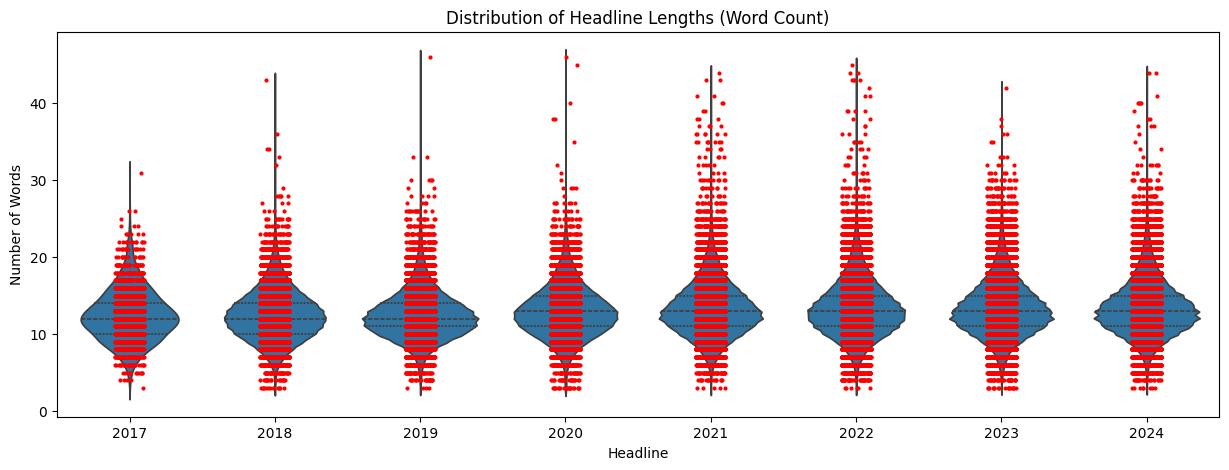

In [16]:
plt.figure(figsize=(15,5))
sns.violinplot(data = processed_gn,y='length',x='year', inner='quartile')
sns.stripplot(data = processed_gn,y='length',x='year', color='red', size=3, jitter=True)
plt.title('Distribution of Headline Lengths (Word Count)')
plt.ylabel('Number of Words')
plt.xlabel('Headline')
plt.show()

In [26]:
# Initialize NLTK components
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Load stopwords
stop_words = set(stopwords.words("english"))

def generate_clean_tokens(text):
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\b\w{21,}\b', '', text)
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]    
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
processed_gn['cleaned'] = processed_gn['News Headline'].apply(lambda x: generate_clean_tokens(x))

In [28]:
processed_gn

,Date,News Headline,Publisher,year,month,month_name,length,cleaned
0,2017-11-09,Hong Kong Fintech Innovation Lab Led with Bloc...,Forbes,2017,11,November,12,"[hong, kong, fintech, innovation, lab, led, bl..."
1,2017-11-09,Decentralized Electricity Could be Blockchain’...,Cointelegraph,2017,11,November,9,"[decentralized, electricity, could, blockchain..."
2,2017-11-09,Ethereum cryptocurrency value dropped due to w...,Inquirer.net,2017,11,November,11,"[ethereum, cryptocurrency, value, dropped, due..."
3,2017-11-09,Ambrosus: Digitalising the Global Trade with B...,Open Access Government,2017,11,November,11,"[ambrosus, digitalising, global, trade, blockc..."
4,2017-11-09,Exchange Comparison: Kraken vs Bitstamp - Coin...,CoinCentral,2017,11,November,7,"[exchange, comparison, kraken, v, bitstamp, co..."
...,...,...,...,...,...,...,...,...
156569,2024-08-11,Monero Price Prediction 2024-2030: A Good Inve...,Cryptopolitan,2024,8,August,9,"[monero, price, prediction, good, investment, ..."
156570,2024-08-11,Could Bitcoin Crash? Celsius Slaps Tether with...,Cryptonews,2024,8,August,14,"[could, bitcoin, crash, celsius, slap, tether,..."
156571,2024-08-11,SEC Addresses Final Court Ruling in Ripple Cas...,Bitcoin.com News,2024,8,August,14,"[sec, address, final, court, ruling, ripple, c..."
156572,2024-08-11,Best Top 5 Crypto to Buy (Short List) / X100 M...,Crypto News Flash,2024,8,August,18,"[best, top, crypto, buy, short, list, x, moons..."


In [29]:
list(processed_gn['cleaned'])

[['hong',
  'kong',
  'fintech',
  'innovation',
  'lab',
  'led',
  'blockchain',
  'ai',
  'forbes'],
 ['decentralized',
  'electricity',
  'could',
  'blockchains',
  'trojan',
  'horse',
  'cointelegraph'],
 ['ethereum',
  'cryptocurrency',
  'value',
  'dropped',
  'due',
  'wallet',
  'security',
  'vulnerability',
  'inquirernet'],
 ['ambrosus',
  'digitalising',
  'global',
  'trade',
  'blockchain',
  'open',
  'access',
  'government'],
 ['exchange', 'comparison', 'kraken', 'v', 'bitstamp', 'coincentral'],
 ['ethereum',
  'creator',
  'wonder',
  'whether',
  'currency',
  'scarcer',
  'economic',
  'time'],
 ['cryptography', 'global', 'health', 'harvard', 'medical', 'school'],
 ['tiny', 'house', 'heated', 'bitcoin', 'mining', 'archivecurbedcom'],
 ['code', 'bug', 'freeze', 'ethereum', 'cryptocash', 'bbccom'],
 ['new', 'blockchain', 'project', 'last', 'year', 'still', 'active', 'cnbc'],
 ['irrational',
  'exuberance',
  'icos',
  'tech',
  'stay',
  'ethereum',
  'cofounder',

In [33]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import CoherenceModel
dictionary= Dictionary(list(processed_gn['cleaned'])) 
bow_corpus = [dictionary.doc2bow(doc) for doc in list(processed_gn['cleaned'])]


# def calculate_coherence_score(corpus, dictionary, texts, num_topics):
#     lda_model = LdaModel(corpus=corpus,
#                          id2word=dictionary,
#                          num_topics=num_topics,
#                          random_state=42,
#                          passes=10)
#     coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
#     coherence_score = coherence_model_lda.get_coherence()
#     perplexity = lda_model.log_perplexity(corpus)
#     return coherence_score, perplexity

# # Lists to store data for plotting
# num_topics_list = []
# coherence_score_list = []
# log_perplexity = []

# # Iterate over different numbers of topics
# min_topics = 1
# max_topics = 10
# step = 1
# for num_topics in range(min_topics, max_topics + 1, step):
#     coherence_score, perplexity = calculate_coherence_score(bow_corpus, dictionary, list(processed_gn['cleaned']), num_topics)
#     print(f"Number of topics: {num_topics}, Coherence Score: {coherence_score}")
#     num_topics_list.append(num_topics)
#     coherence_score_list.append(coherence_score)
#     log_perplexity.append(perplexity)

# # Plotting coherence score vs. number of topics
# plt.plot(num_topics_list, coherence_score_list)
# plt.plot(num_topics_list, log_perplexity)
# plt.xlabel("Number of Topics")
# plt.ylabel("Coherence Score")
# plt.title("Coherence Score vs. Number of Topics")
# plt.show()

# # Find the best number of topics based on the maximum coherence score
# best_num_topics = num_topics_list[coherence_score_list.index(max(coherence_score_list))]
# best_coherence_score = max(coherence_score_list)
# print(f"Best number of topics: {best_num_topics}, Best coherence score: {best_coherence_score}")


# This call will construct and fit (train) the LDA model:
lda_model =  LdaModel(bow_corpus, 
                      num_topics=5, 
                      id2word=dictionary,                                    
                      passes=10,
                    )

def get_lda_topics(model, num_topics, top_n_words):
     word_dict = []
     for i in range(num_topics):
         word_dict.extend([i[0] for i in model.show_topic(i, topn = top_n_words)])
     return word_dict
x = get_lda_topics(lda_model,5,10)


In [34]:
x

['news',
 'bitcoin',
 'cryptocurrency',
 'crypto',
 'bitcoincom',
 'ethereum',
 'mining',
 'rally',
 'million',
 'coin',
 'blockchain',
 'cryptonews',
 'xrp',
 'ripple',
 'cryptoslate',
 'technology',
 'fxstreet',
 'ltc',
 'ai',
 'global',
 'etf',
 'crypto',
 'cryptocurrency',
 'spot',
 'time',
 'bitcoin',
 'sec',
 'blockchainnews',
 'new',
 'u',
 'bitcoin',
 'ethereum',
 'price',
 'crypto',
 'eth',
 'market',
 'k',
 'btc',
 'finance',
 'cointelegraph',
 'blockchain',
 'news',
 'ethereum',
 'crypto',
 'solana',
 'insight',
 'launch',
 'fintech',
 'coinpedia',
 'analytics']